## <span style="color:grey; font-weight:bold;">Import Tools and Def Functions</span>

In [1]:
import pandas as pd
import os
import missingno as msno

In [2]:
from Def_Function import RenameandCheckDuplicateandNaN, ColumnsNaNSorted, RemovedColumnOver50, SeparateNumericalandObjective
from Def_Function import ColumnsHist, CorrHeatMap, CountStatistic, ImputeNaN, ObjectiveLabelEncoder, NaNColumns, MergeAllTypeofColumns
from Def_Function import FilterColumns, DropSpecificRowNaN, ModelFillNaN, CheckNegativeColumns, SkewCountingandTransformWithoutHist
from Def_Function import BoxPlot, IQRRemoveOutlier, ExtremeRemoveOutlier, SaveCSV

In [3]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
data_path = '/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Data'
os.chdir(data_path)

files = os.listdir()
print(files)

['2.All FillNan Chunk 5.csv', '2.All FillNan Chunk 4.csv', '.DS_Store', '2.All FillNan Chunk 1.csv', '2.All FillNan Chunk 3.csv', '2.All FillNan Chunk 2.csv', 'train.txt', 'encoder_dict.joblib', 'Base Train DataFrame Chunk3.csv', '3.Final Chunk 2.csv', '1.Row Objective Chunk 1.csv', '3.Final Chunk 3.csv', 'Base Train DataFrame Chunk2.csv', '3.Final Chunk 1.csv', '1.Row Objective Chunk 2.csv', '1.Row Objective Chunk 3.csv', 'Base Train DataFrame Chunk1.csv', 'Base Train DataFrame Chunk5.csv', '3.Final Chunk 4.csv', '3.Final Chunk 5.csv', 'Base Train DataFrame Chunk4.csv', '1.Row Objective Chunk 4.csv', '1.Row Objective Chunk 5.csv', 'readme.txt', 'test.txt', '0.FillNan Numerical Chunk 1.csv', '0.FillNan Numerical Chunk 2.csv', '0.FillNan Numerical Chunk 3.csv', '0.FillNan Numerical Chunk 4.csv', '0.FillNan Numerical Chunk 5.csv']


## <span style="color:skyblue; font-weight:bold;">Train Chunk 2</span>

#### <span style="color:grey; font-weight:bold;">Numerical Chunk 2</span>

In [6]:
train_df_chunk2 = pd.read_csv('Base Train DataFrame Chunk2.csv', sep=',')
train_df_chunk2

,0,1,1.1,5,0.1,1382,4,15,2,181,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,Unnamed: 35,3a171ecb,c5c50484,e8b83407,9727dd16
0,1,1.00,156,NaN,NaN,492.00,57.00,1.00,34.00,206.00,...,8efede7f,88416823,NaN,NaN,114dc0d0,ad3062eb,423fab69,e5fca70a,NaN,NaN
1,0,NaN,101,11.00,11.00,4216.00,68.00,6.00,11.00,355.00,...,3486227d,e96a7df2,NaN,NaN,1c8f9570,NaN,423fab69,cafb4e4d,NaN,NaN
2,0,1.00,7,NaN,9.00,1.00,9.00,71.00,9.00,408.00,...,3486227d,9880032b,21ddcdc9,5840adea,0bf1a149,NaN,423fab69,72e6747e,ea9a246c,aa5f0a15
3,1,9.00,1,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,e5ba7672,f855e3f0,21ddcdc9,5840adea,572bdde8,NaN,32c7478e,9fa3e01a,001f3601,414c6af0
4,0,0.00,7,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,e5ba7672,582152eb,21ddcdc9,5840adea,bc907bb4,NaN,32c7478e,eb251029,001f3601,aa5f0a15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0,NaN,0,18.00,12.00,2.00,NaN,0.00,4.00,12.00,...,e5ba7672,891589e7,21ddcdc9,5840adea,NaN,NaN,32c7478e,NaN,ea9a246c,2ddaef64
9999996,0,12.00,0,2.00,3.00,685.00,4.00,17.00,39.00,66.00,...,e5ba7672,8cd9b2d3,NaN,NaN,3067dbd3,ad3062eb,32c7478e,ec498394,NaN,NaN
9999997,0,NaN,-1,NaN,NaN,22658.00,1.00,1.00,0.00,0.00,...,d4bb7bd8,744ad4a0,NaN,NaN,a17a10b3,c9d4222a,3a171ecb,e5fca70a,NaN,NaN
9999998,0,0.00,0,NaN,NaN,9722.00,NaN,0.00,10.00,1.00,...,8efede7f,fc923ad0,NaN,NaN,0014c32a,NaN,32c7478e,3b183c5c,NaN,NaN


In [7]:
train_df_chunk2.describe()

,0,1,1.1,5,0.1,1382,4,15,2,181,1.2,2.1,Unnamed: 12,2.2
count,10000000.00,5416429.00,10000000.00,7894643.00,7881729.00,9713583.00,7696428.00,9557173.00,9995012.00,9557173.00,5416429.00,9557173.00,2271204.00,7881729.00
mean,0.26,3.72,106.52,27.80,7.49,18627.99,117.59,16.28,12.62,103.35,0.64,2.69,0.83,8.50
std,0.44,10.06,399.08,383.09,8.98,69764.27,386.11,67.12,14.97,218.81,0.69,5.22,4.74,14.90
min,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,2.00,2.00,295.00,8.00,1.00,2.00,10.00,0.00,1.00,0.00,2.00
50%,0.00,1.00,3.00,6.00,4.00,2809.00,33.00,3.00,7.00,37.00,1.00,1.00,0.00,4.00
75%,1.00,4.00,37.00,18.00,10.00,10370.00,103.00,11.00,19.00,105.00,1.00,3.00,0.00,11.00
max,1.00,2344.00,257675.00,65535.00,635.00,23159456.00,250468.00,24393.00,3833.00,29019.00,10.00,165.00,1881.00,7086.00


In [8]:
train_chunk2= RenameandCheckDuplicateandNaN(train_df_chunk2)

Rename is Finished.
Duplicates Found.
Duplicates Rows Count: 1121
New Shape After Removing Duplicates: (9998879, 40)
NaN Found.
Total NaN Value: 55519994



In [9]:
ColumnsNaNSorted(train_chunk2)

35   78.26
12   77.29
1    45.83
10   45.83
39   42.44
38   42.44
33   42.44
32   42.44
6    23.03
4    21.18
13   21.18
3    21.05
19   14.22
11    4.42
7     4.42
9     4.42
34    3.58
25    3.58
37    3.58
17    3.58
16    3.58
29    3.58
5     2.85
8     0.05
dtype: float64



,Predicted,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,1,1.00,156,NaN,NaN,492.00,57.00,1.00,34.00,206.00,...,8efede7f,88416823,NaN,NaN,114dc0d0,ad3062eb,423fab69,e5fca70a,NaN,NaN
1,0,NaN,101,11.00,11.00,4216.00,68.00,6.00,11.00,355.00,...,3486227d,e96a7df2,NaN,NaN,1c8f9570,NaN,423fab69,cafb4e4d,NaN,NaN
2,0,1.00,7,NaN,9.00,1.00,9.00,71.00,9.00,408.00,...,3486227d,9880032b,21ddcdc9,5840adea,0bf1a149,NaN,423fab69,72e6747e,ea9a246c,aa5f0a15
3,1,9.00,1,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,e5ba7672,f855e3f0,21ddcdc9,5840adea,572bdde8,NaN,32c7478e,9fa3e01a,001f3601,414c6af0
4,0,0.00,7,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,e5ba7672,582152eb,21ddcdc9,5840adea,bc907bb4,NaN,32c7478e,eb251029,001f3601,aa5f0a15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0,NaN,0,18.00,12.00,2.00,NaN,0.00,4.00,12.00,...,e5ba7672,891589e7,21ddcdc9,5840adea,NaN,NaN,32c7478e,NaN,ea9a246c,2ddaef64
9999996,0,12.00,0,2.00,3.00,685.00,4.00,17.00,39.00,66.00,...,e5ba7672,8cd9b2d3,NaN,NaN,3067dbd3,ad3062eb,32c7478e,ec498394,NaN,NaN
9999997,0,NaN,-1,NaN,NaN,22658.00,1.00,1.00,0.00,0.00,...,d4bb7bd8,744ad4a0,NaN,NaN,a17a10b3,c9d4222a,3a171ecb,e5fca70a,NaN,NaN
9999998,0,0.00,0,NaN,NaN,9722.00,NaN,0.00,10.00,1.00,...,8efede7f,fc923ad0,NaN,NaN,0014c32a,NaN,32c7478e,3b183c5c,NaN,NaN


In [10]:
RemovedColumnOver50(train_chunk2)

Removed Columns List: ['35', '12']



,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,1,1.00,156,NaN,NaN,492.00,57.00,1.00,34.00,206.00,...,d32b8b58,8efede7f,88416823,NaN,NaN,114dc0d0,423fab69,e5fca70a,NaN,NaN
1,0,NaN,101,11.00,11.00,4216.00,68.00,6.00,11.00,355.00,...,dba66dd1,3486227d,e96a7df2,NaN,NaN,1c8f9570,423fab69,cafb4e4d,NaN,NaN
2,0,1.00,7,NaN,9.00,1.00,9.00,71.00,9.00,408.00,...,d9f625bc,3486227d,9880032b,21ddcdc9,5840adea,0bf1a149,423fab69,72e6747e,ea9a246c,aa5f0a15
3,1,9.00,1,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,0fd4fbad,e5ba7672,f855e3f0,21ddcdc9,5840adea,572bdde8,32c7478e,9fa3e01a,001f3601,414c6af0
4,0,0.00,7,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,c5e472ab,e5ba7672,582152eb,21ddcdc9,5840adea,bc907bb4,32c7478e,eb251029,001f3601,aa5f0a15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0,NaN,0,18.00,12.00,2.00,NaN,0.00,4.00,12.00,...,NaN,e5ba7672,891589e7,21ddcdc9,5840adea,NaN,32c7478e,NaN,ea9a246c,2ddaef64
9999996,0,12.00,0,2.00,3.00,685.00,4.00,17.00,39.00,66.00,...,b8025ae9,e5ba7672,8cd9b2d3,NaN,NaN,3067dbd3,32c7478e,ec498394,NaN,NaN
9999997,0,NaN,-1,NaN,NaN,22658.00,1.00,1.00,0.00,0.00,...,fae7560f,d4bb7bd8,744ad4a0,NaN,NaN,a17a10b3,3a171ecb,e5fca70a,NaN,NaN
9999998,0,0.00,0,NaN,NaN,9722.00,NaN,0.00,10.00,1.00,...,84898b2a,8efede7f,fc923ad0,NaN,NaN,0014c32a,32c7478e,3b183c5c,NaN,NaN


In [11]:
numerical_chunk2, objective_chunk2 = SeparateNumericalandObjective(train_chunk2)

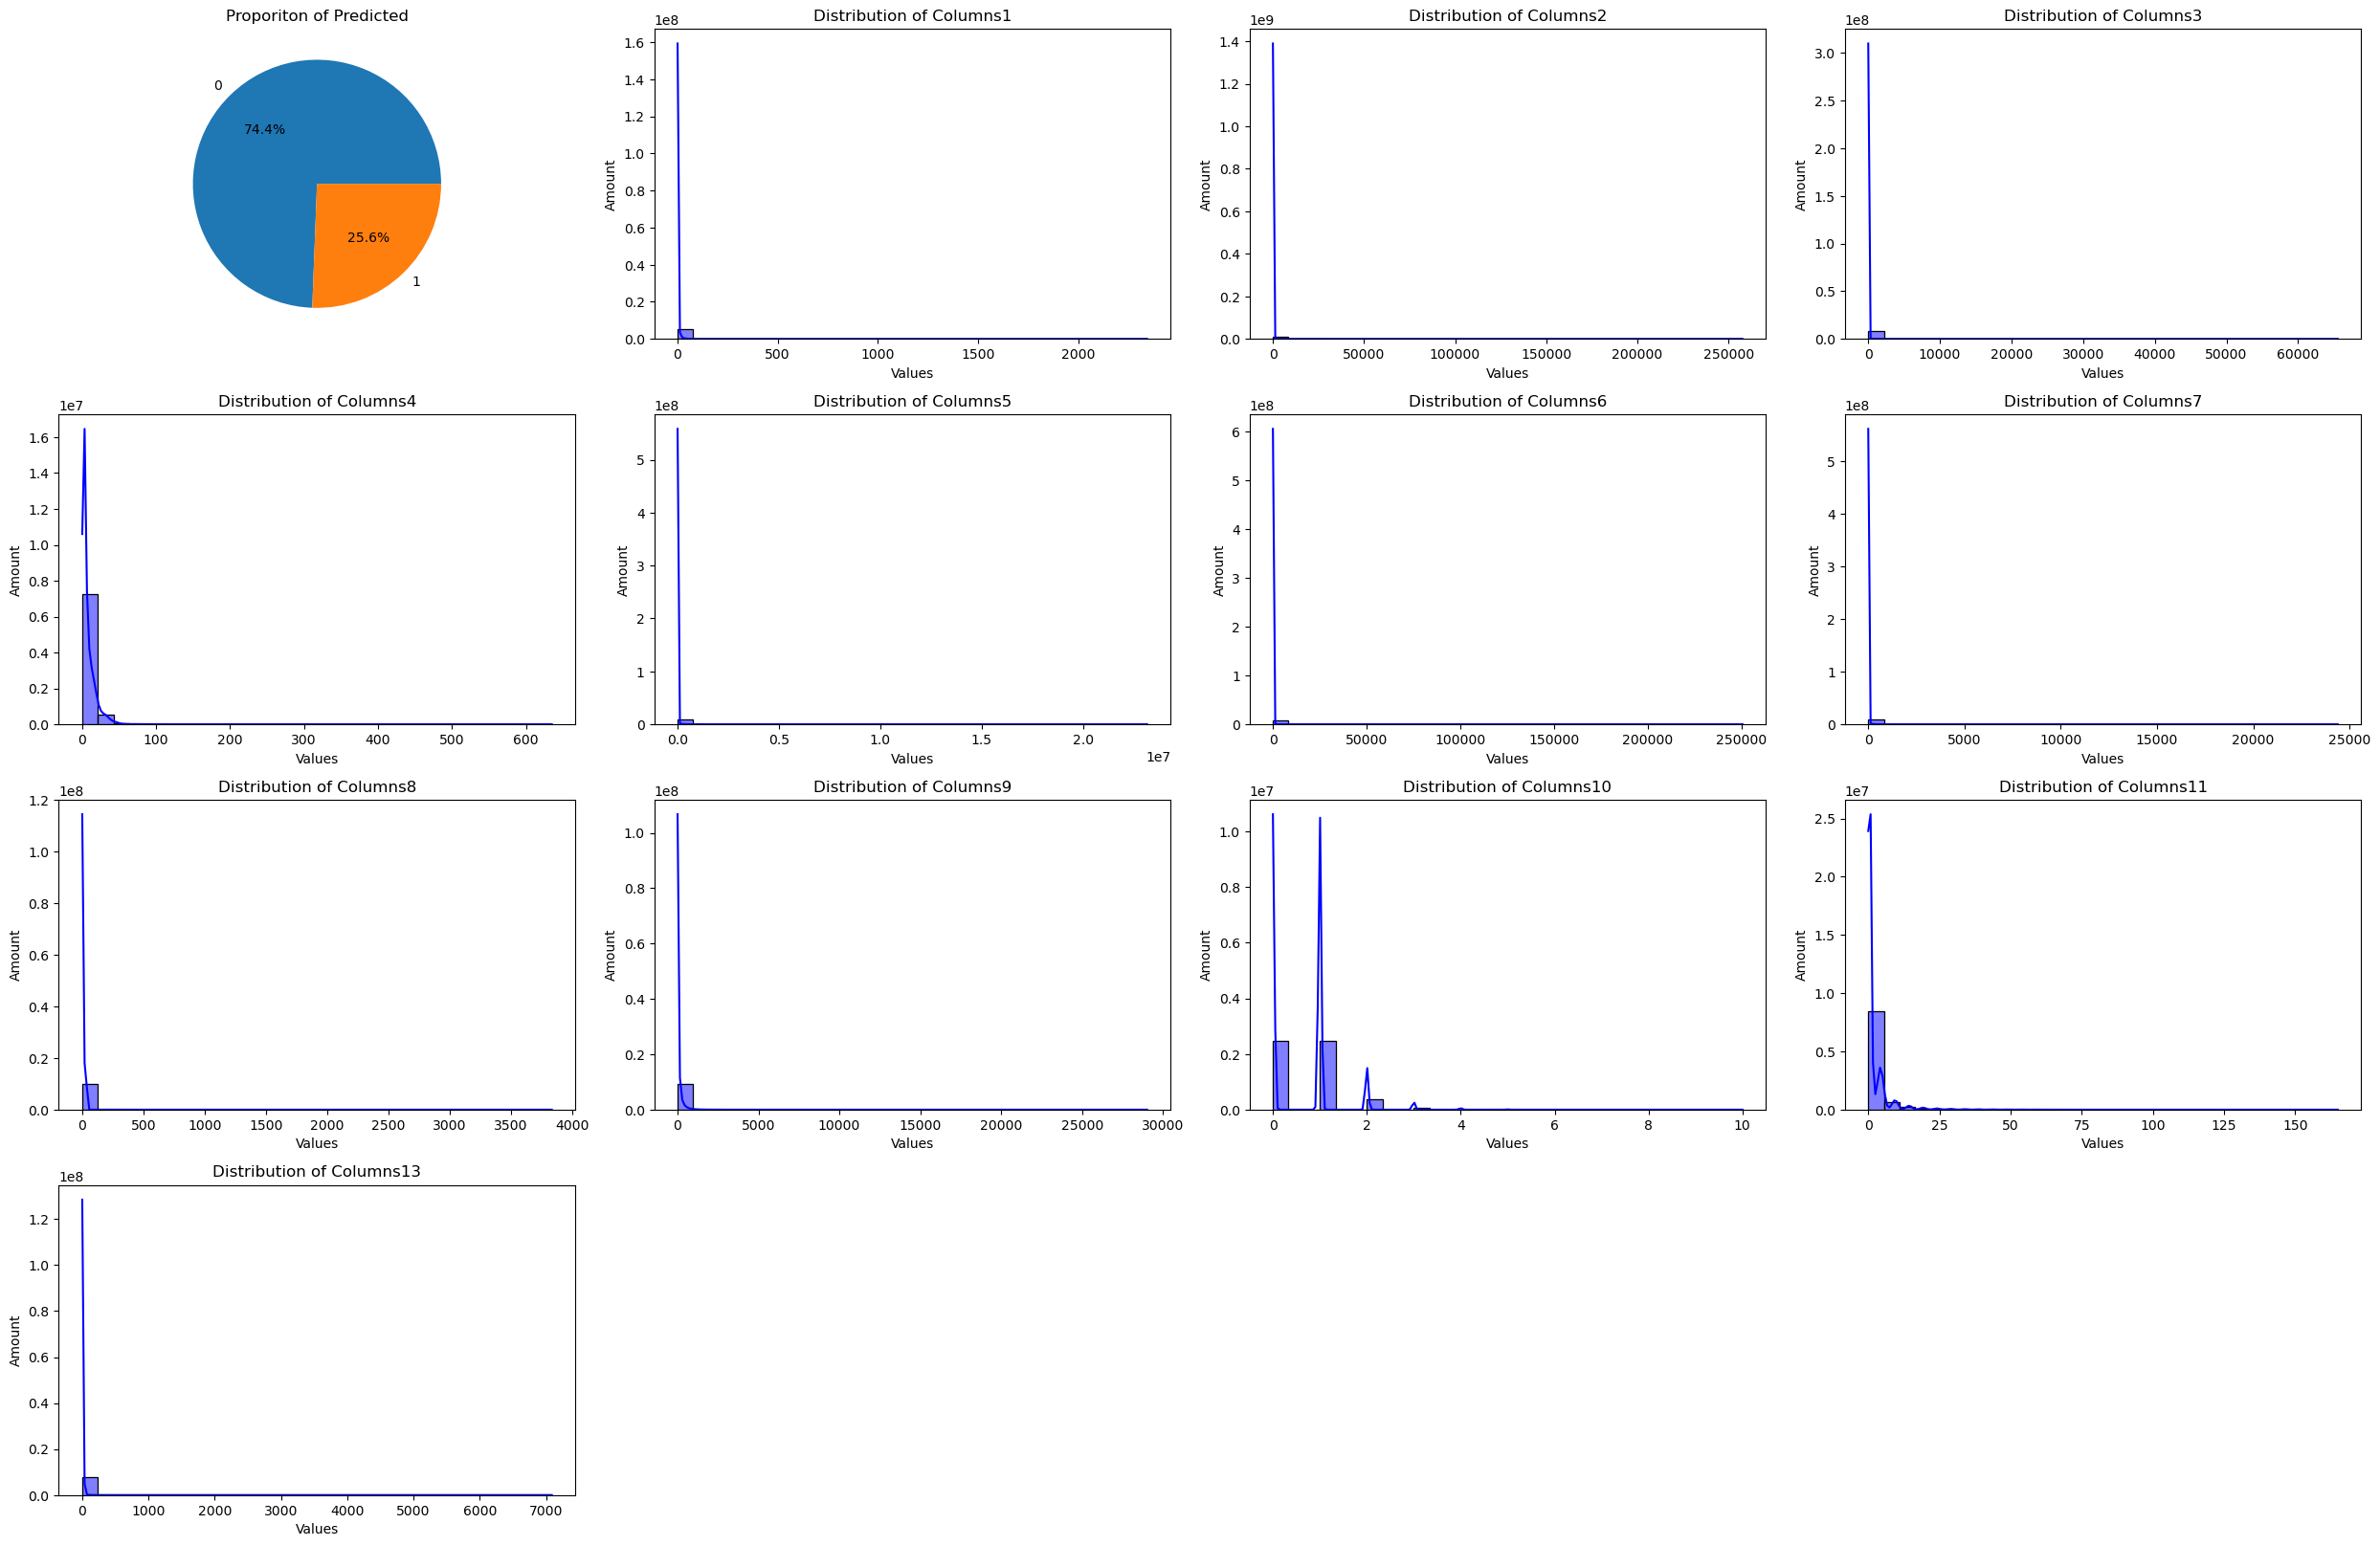

In [12]:
ColumnsHist(numerical_chunk2)

In [13]:
numerical_chunk2 = ImputeNaN(numerical_chunk2)

Predicted    0
1            0
2            0
3            0
4            0
5            0
6            0
7            0
8            0
9            0
10           0
11           0
13           0
dtype: int64



In [14]:
SaveCSV(numerical_chunk2, '0.FillNan Numerical', '2')
SaveCSV(objective_chunk2, '1.Row Objective', '2')

Saved 0.FillNan Numerical Chunk 2
Saved 1.Row Objective Chunk 2


#### <span style="color:grey; font-weight:bold;">Objective Chunk 2</span>

In [15]:
# objective_chunk2 = pd.read_csv('1.Row Objective Chunk 2.csv', sep=',')

In [19]:
objective_chunk2 = ObjectiveLabelEncoder(objective_chunk2)
objective_chunk2

encoder_dict is None
Joblib Saved



,Predicted,14,15,16,17,18,19,20,21,22,...,29,30,31,32,33,34,36,37,38,39
0,1,31,142,1025735,511745,109,19,1030,130,2,...,1320778,6,2608,NaN,NaN,134618,4,121220,NaN,NaN
1,0,31,125,33331,371149,109,21,1620,24,2,...,1374266,4,4518,NaN,NaN,222602,4,107207,NaN,NaN
2,0,31,11,724005,412326,43,8,7893,227,2,...,1363467,4,2936,265,0,92912,4,60591,88,56700
3,1,1382,127,1850835,557197,43,8,7224,201,2,...,99273,9,4809,265,0,678638,2,84109,0,21428
4,0,546,127,1795916,458360,43,NaN,4457,227,2,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0,31,87,NaN,NaN,43,19,9534,24,2,...,NaN,9,2625,265,0,NaN,2,NaN,88,15113
9999996,0,626,125,1372396,165295,43,19,11203,411,2,...,1150524,9,2687,NaN,NaN,377124,2,124578,NaN,NaN
9999997,0,626,142,2006864,339811,43,19,4538,24,0,...,1569369,8,2225,NaN,NaN,1257967,3,121220,NaN,NaN
9999998,0,31,204,2146119,550423,43,8,5468,80,2,...,829577,6,4895,NaN,NaN,617,2,31155,NaN,NaN


In [20]:
ColumnsNaNSorted(objective_chunk2)

39   42.44
38   42.44
33   42.44
32   42.44
19   14.22
16    3.58
17    3.58
37    3.58
34    3.58
25    3.58
29    3.58
dtype: float64



,Predicted,14,15,16,17,18,19,20,21,22,...,29,30,31,32,33,34,36,37,38,39
0,1,31,142,1025735,511745,109,19,1030,130,2,...,1320778,6,2608,NaN,NaN,134618,4,121220,NaN,NaN
1,0,31,125,33331,371149,109,21,1620,24,2,...,1374266,4,4518,NaN,NaN,222602,4,107207,NaN,NaN
2,0,31,11,724005,412326,43,8,7893,227,2,...,1363467,4,2936,265,0,92912,4,60591,88,56700
3,1,1382,127,1850835,557197,43,8,7224,201,2,...,99273,9,4809,265,0,678638,2,84109,0,21428
4,0,546,127,1795916,458360,43,NaN,4457,227,2,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0,31,87,NaN,NaN,43,19,9534,24,2,...,NaN,9,2625,265,0,NaN,2,NaN,88,15113
9999996,0,626,125,1372396,165295,43,19,11203,411,2,...,1150524,9,2687,NaN,NaN,377124,2,124578,NaN,NaN
9999997,0,626,142,2006864,339811,43,19,4538,24,0,...,1569369,8,2225,NaN,NaN,1257967,3,121220,NaN,NaN
9999998,0,31,204,2146119,550423,43,8,5468,80,2,...,829577,6,4895,NaN,NaN,617,2,31155,NaN,NaN


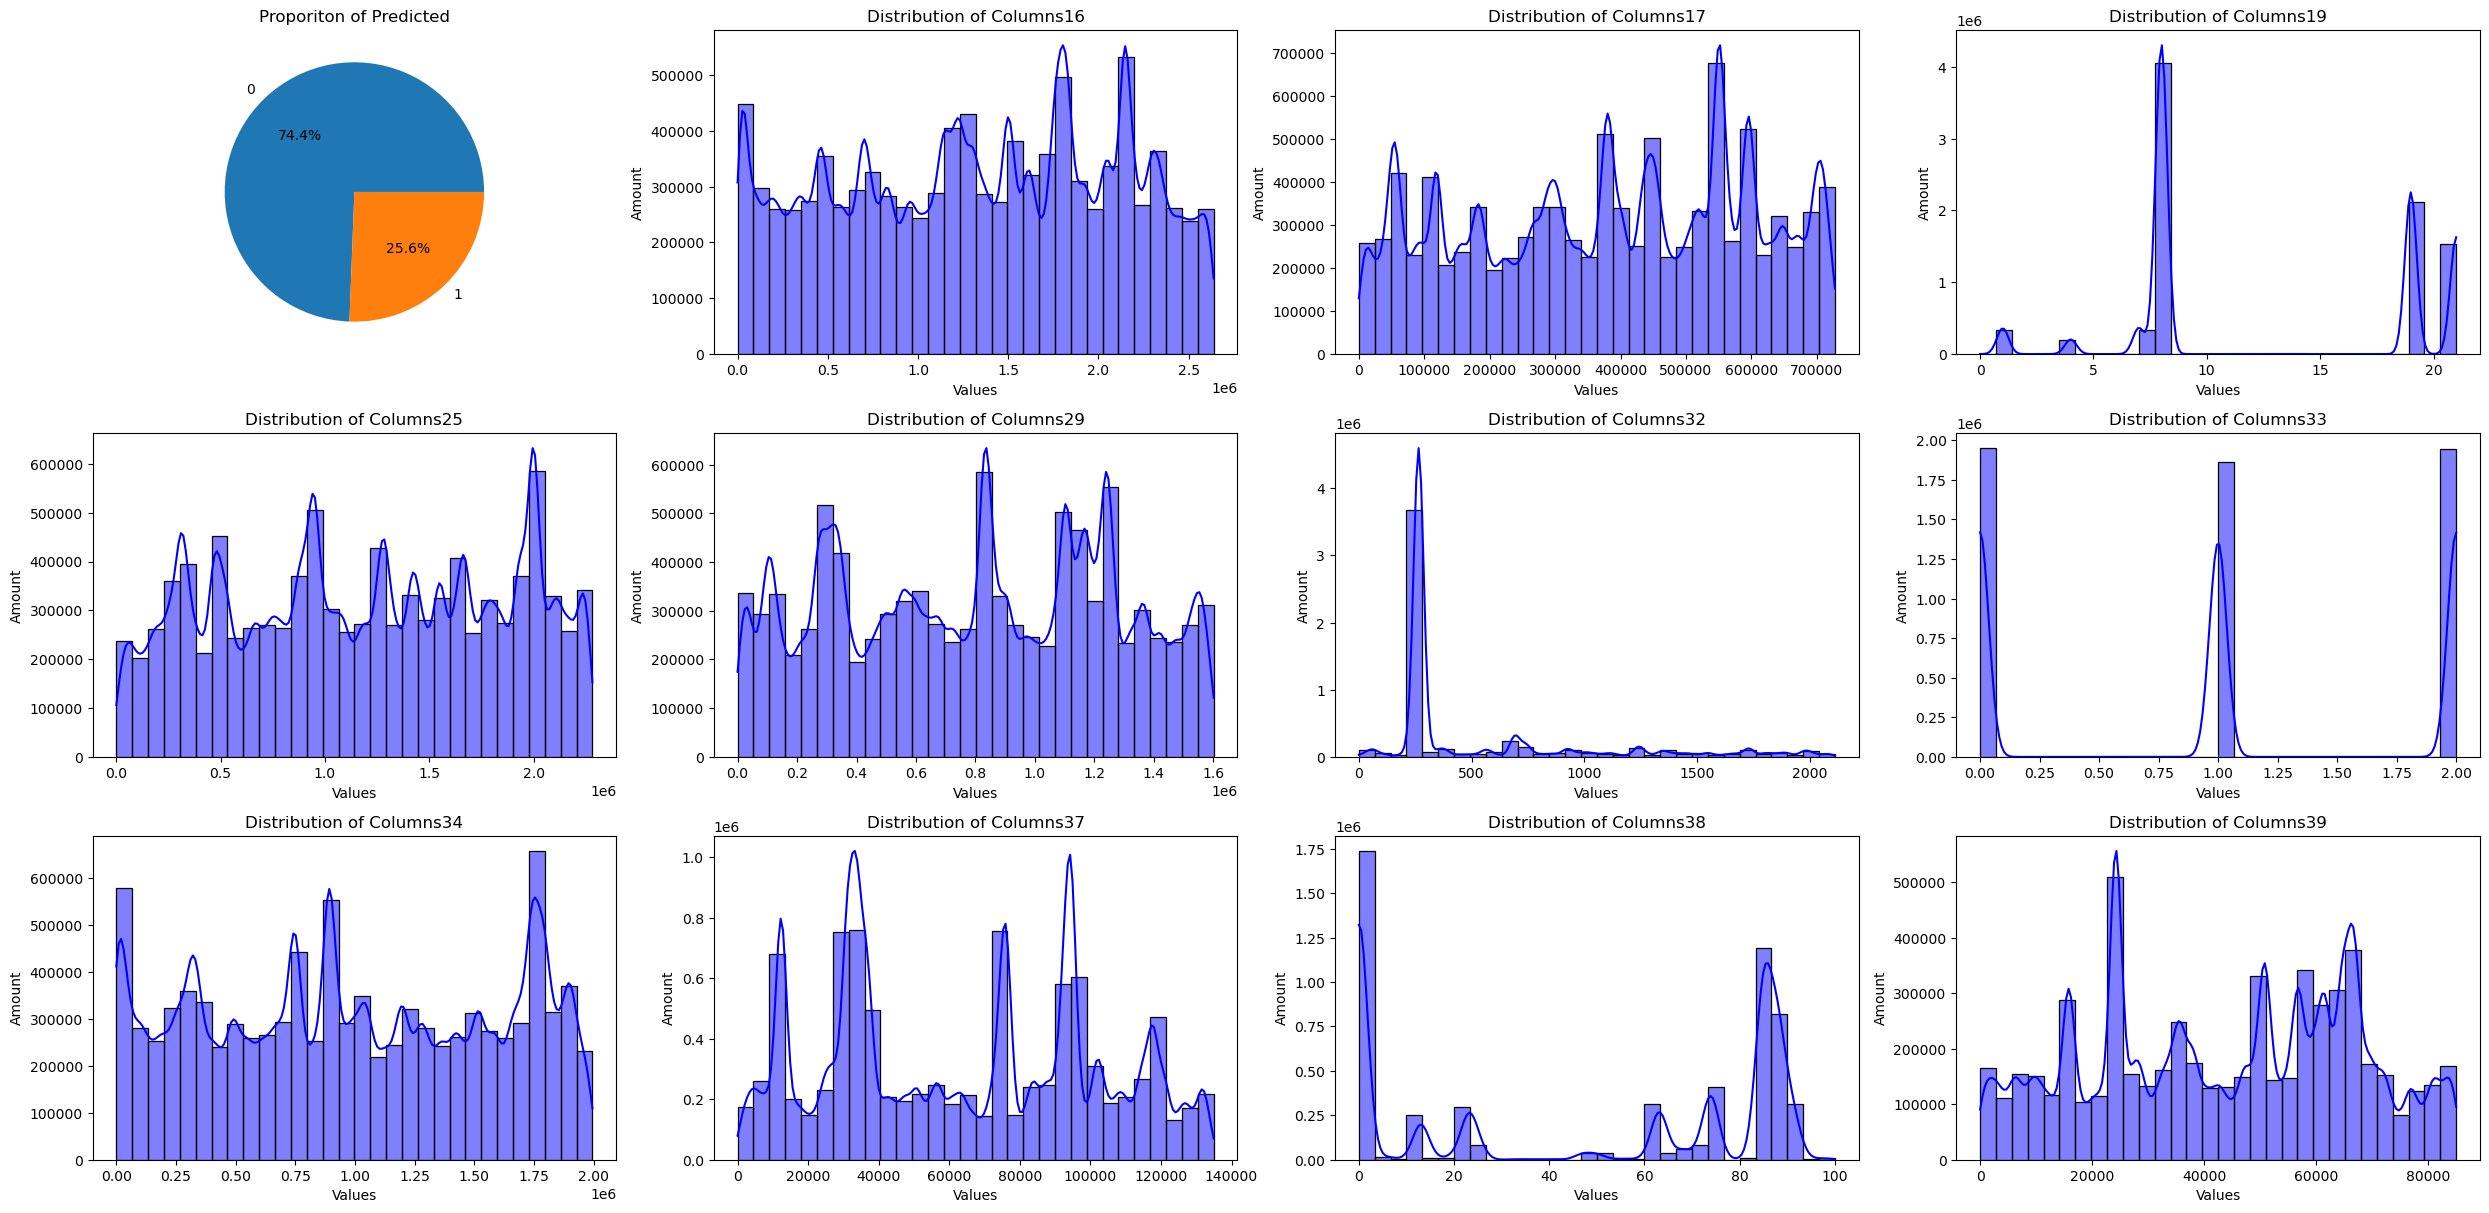

In [21]:
objective_missing_col2 = NaNColumns(objective_chunk2)
ColumnsHist(objective_missing_col2)

#### <span style="color:grey; font-weight:bold;">Merge Columns and Drop or Fill NaN</span>

In [22]:
# numerical_chunk2 = pd.read_csv('0.FillNan Numerical Chunk 2.csv', sep=',')
# objective_chunk2 = pd.read_csv('1.Row Objective Chunk 2.csv', sep=',')

In [23]:
all_col_chunk2 = MergeAllTypeofColumns(numerical_chunk2, objective_chunk2)
all_col_chunk2

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,1.00,1.00,156.00,6.00,4.00,492.00,57.00,1.00,34.00,206.00,...,1320778,6,2608,NaN,NaN,134618,4,121220,NaN,NaN
1,0.00,1.00,101.00,11.00,11.00,4216.00,68.00,6.00,11.00,355.00,...,1374266,4,4518,NaN,NaN,222602,4,107207,NaN,NaN
2,0.00,1.00,7.00,6.00,9.00,1.00,9.00,71.00,9.00,408.00,...,1363467,4,2936,265,0,92912,4,60591,88,56700
3,1.00,9.00,1.00,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,99273,9,4809,265,0,678638,2,84109,0,21428
4,0.00,0.00,7.00,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0.00,1.00,0.00,18.00,12.00,2.00,33.00,0.00,4.00,12.00,...,NaN,9,2625,265,0,NaN,2,NaN,88,15113
9999996,0.00,12.00,0.00,2.00,3.00,685.00,4.00,17.00,39.00,66.00,...,1150524,9,2687,NaN,NaN,377124,2,124578,NaN,NaN
9999997,0.00,1.00,-1.00,6.00,4.00,22658.00,1.00,1.00,0.00,0.00,...,1569369,8,2225,NaN,NaN,1257967,3,121220,NaN,NaN
9999998,0.00,0.00,0.00,6.00,4.00,9722.00,33.00,0.00,10.00,1.00,...,829577,6,4895,NaN,NaN,617,2,31155,NaN,NaN


In [24]:
ColumnsNaNSorted(all_col_chunk2)

39   42.44
38   42.44
33   42.44
32   42.44
19   14.22
25    3.58
17    3.58
16    3.58
29    3.58
34    3.58
37    3.58
dtype: float64



,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,1.00,1.00,156.00,6.00,4.00,492.00,57.00,1.00,34.00,206.00,...,1320778,6,2608,NaN,NaN,134618,4,121220,NaN,NaN
1,0.00,1.00,101.00,11.00,11.00,4216.00,68.00,6.00,11.00,355.00,...,1374266,4,4518,NaN,NaN,222602,4,107207,NaN,NaN
2,0.00,1.00,7.00,6.00,9.00,1.00,9.00,71.00,9.00,408.00,...,1363467,4,2936,265,0,92912,4,60591,88,56700
3,1.00,9.00,1.00,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,99273,9,4809,265,0,678638,2,84109,0,21428
4,0.00,0.00,7.00,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,0.00,1.00,0.00,18.00,12.00,2.00,33.00,0.00,4.00,12.00,...,NaN,9,2625,265,0,NaN,2,NaN,88,15113
9999996,0.00,12.00,0.00,2.00,3.00,685.00,4.00,17.00,39.00,66.00,...,1150524,9,2687,NaN,NaN,377124,2,124578,NaN,NaN
9999997,0.00,1.00,-1.00,6.00,4.00,22658.00,1.00,1.00,0.00,0.00,...,1569369,8,2225,NaN,NaN,1257967,3,121220,NaN,NaN
9999998,0.00,0.00,0.00,6.00,4.00,9722.00,33.00,0.00,10.00,1.00,...,829577,6,4895,NaN,NaN,617,2,31155,NaN,NaN


<Axes: >

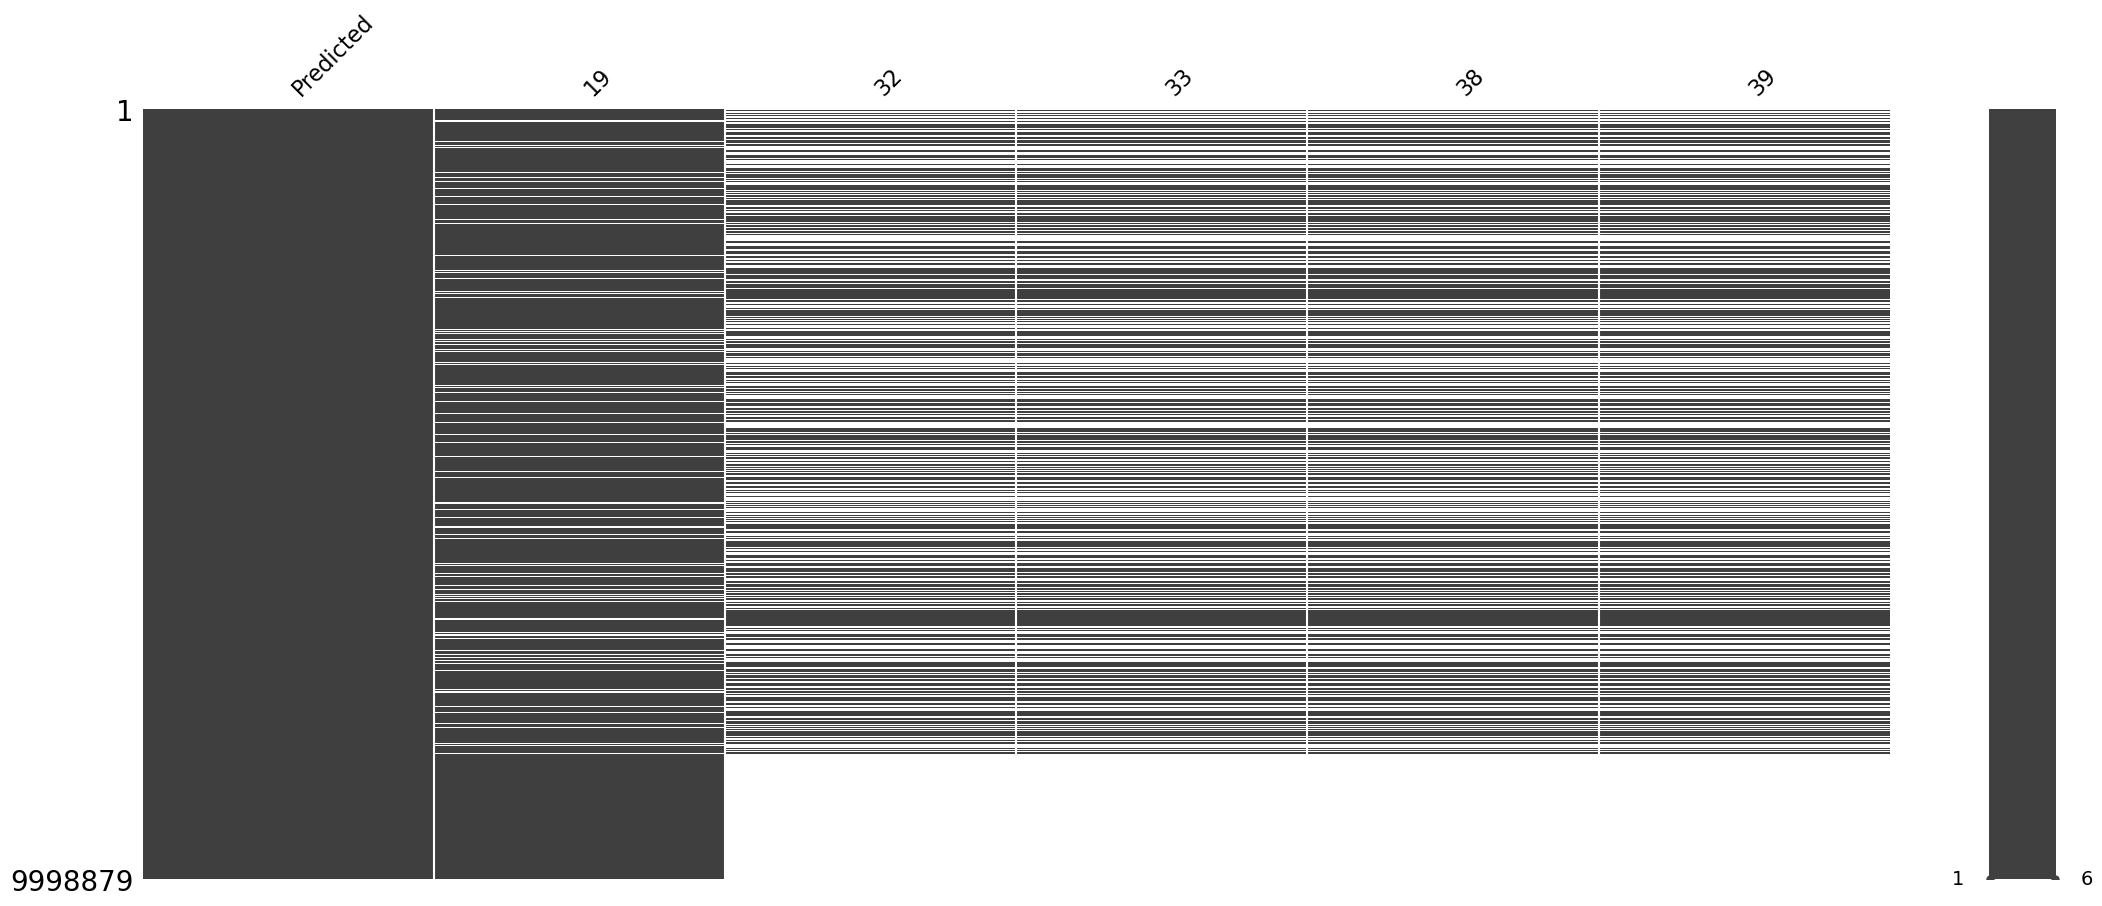

In [25]:
msno.matrix(all_col_chunk2[['Predicted', '19', '32', '33', '38', '39']])

In [27]:
filterd_columns = FilterColumns(all_col_chunk2, '19')
drop_col_chunk2 = DropSpecificRowNaN(all_col_chunk2, filterd_columns)
drop_col_chunk2

Row Before Drop: 9998879
Row After Drop: 5676811
Columns 16 Missing After Drop: 0
Columns 17 Missing After Drop: 0
Columns 25 Missing After Drop: 0
Columns 29 Missing After Drop: 0
Columns 32 Missing After Drop: 0
Columns 33 Missing After Drop: 0
Columns 34 Missing After Drop: 0
Columns 37 Missing After Drop: 0
Columns 38 Missing After Drop: 0
Columns 39 Missing After Drop: 0


,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,1.00,7.00,6.00,9.00,1.00,9.00,71.00,9.00,408.00,...,1363467,4,2936,265,0,92912,4,60591,88,56700
1,1.00,9.00,1.00,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,99273,9,4809,265,0,678638,2,84109,0,21428
2,0.00,0.00,7.00,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
3,0.00,1.00,1.00,12.00,1.00,40419.00,33.00,3.00,1.00,37.00,...,1102114,0,4791,265,1,1815714,2,133601,0,63809
4,0.00,0.00,0.00,8.00,1.00,4744.00,136.00,46.00,2.00,956.00,...,1292242,9,4183,265,0,1492445,2,57401,73,50674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676806,0.00,0.00,0.00,7.00,2.00,2282.00,23.00,12.00,9.00,211.00,...,863655,6,4956,265,2,11878,2,117730,0,64613
5676807,1.00,62.00,0.00,33.00,20.00,2.00,2.00,1378.00,20.00,1051.00,...,607918,9,2354,1460,1,660631,4,20011,85,5885
5676808,0.00,0.00,146.00,4.00,4.00,2695.00,81.00,1.00,22.00,38.00,...,891243,8,4956,265,2,1052032,2,117730,0,64613
5676809,0.00,1.00,191.00,4.00,13.00,10887.00,115.00,6.00,12.00,241.00,...,674677,3,2959,265,2,1113893,2,75783,0,80859


In [28]:
ModelFillNaN(drop_col_chunk2, '19')

/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Def_Function.py:266: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[col] = predicted


Columns 19 FillNaN is Finished



,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,1.00,7.00,6.00,9.00,1.00,9.00,71.00,9.00,408.00,...,1363467,4,2936,265,0,92912,4,60591,88,56700
1,1.00,9.00,1.00,0.00,10.00,2.00,1.00,9.00,10.00,10.00,...,99273,9,4809,265,0,678638,2,84109,0,21428
2,0.00,0.00,7.00,4.00,9.00,1399.00,34.00,25.00,49.00,263.00,...,1237653,9,1668,265,0,1469583,2,123981,0,56700
3,0.00,1.00,1.00,12.00,1.00,40419.00,33.00,3.00,1.00,37.00,...,1102114,0,4791,265,1,1815714,2,133601,0,63809
4,0.00,0.00,0.00,8.00,1.00,4744.00,136.00,46.00,2.00,956.00,...,1292242,9,4183,265,0,1492445,2,57401,73,50674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676806,0.00,0.00,0.00,7.00,2.00,2282.00,23.00,12.00,9.00,211.00,...,863655,6,4956,265,2,11878,2,117730,0,64613
5676807,1.00,62.00,0.00,33.00,20.00,2.00,2.00,1378.00,20.00,1051.00,...,607918,9,2354,1460,1,660631,4,20011,85,5885
5676808,0.00,0.00,146.00,4.00,4.00,2695.00,81.00,1.00,22.00,38.00,...,891243,8,4956,265,2,1052032,2,117730,0,64613
5676809,0.00,1.00,191.00,4.00,13.00,10887.00,115.00,6.00,12.00,241.00,...,674677,3,2959,265,2,1113893,2,75783,0,80859


In [29]:
SaveCSV(drop_col_chunk2, '2.All FillNan', '2')

Saved 2.All FillNan Chunk 2


#### <span style="color:grey; font-weight:bold;">Skew and Remove Outlier</span>

In [5]:
drop_col_chunk2 = pd.read_csv('2.All FillNan Chunk 2.csv', sep=',')

In [6]:
numerical_df2 = drop_col_chunk2.loc[:, 'Predicted':'13']
objective_df2 = drop_col_chunk2.loc[:, '14':]

In [7]:
negative_list = CheckNegativeColumns(numerical_df2)
print(negative_list)

Columns 2 including negative number
-2.0
['2']


In [8]:
SkewCountingandTransformWithoutHist(numerical_df2, negative_list)

Procseeing 1
Original Column 1 Skew: 26.23
Column 1 transform by Boxcox has lower Skew: 0.07
Procseeing 2
Original Column 2 Skew: 57.19
Column 2 had been shifted Because it including negative: 1.17
Procseeing 3
Original Column 3 Skew: 72.26
Column 3 transform by Boxcox has lower Skew: 0.05
Procseeing 4
Original Column 4 Skew: 2.93
Column 4 transform by Boxcox has lower Skew: 0.00
Procseeing 5
Original Column 5 Skew: 14.59
Column 5 transform by Boxcox has lower Skew: -0.03
Procseeing 6
Original Column 6 Skew: 68.45
Column 6 transform by Boxcox has lower Skew: 0.01
Procseeing 7
Original Column 7 Skew: 34.11
Column 7 transform by Boxcox has lower Skew: 0.10
Procseeing 8
Original Column 8 Skew: 1.14
Column 8 transform by Boxcox has lower Skew: -0.06
Procseeing 9
Original Column 9 Skew: 9.59
Column 9 transform by Boxcox has lower Skew: -0.00
Procseeing 10
Original Column 10 Skew: 0.50
Columns 10 Skew is not in range for transform
Procseeing 11
Original Column 11 Skew: 6.02
Column 11 transfo

,Predicted,1,2,3,4,5,6,7,8,9,10,11,13
0,0.00,0.56,2.30,1.55,2.04,0.71,2.42,2.70,2.73,6.84,1.00,1.48,2.00
1,1.00,1.18,1.39,0.00,2.11,1.15,0.70,1.78,2.86,2.52,1.00,0.59,0.00
2,0.00,0.00,2.30,1.34,2.04,10.00,3.84,2.28,5.25,6.28,0.00,1.14,2.00
3,0.00,0.56,1.39,1.92,0.67,17.18,3.81,1.18,0.73,3.93,1.00,0.59,0.66
4,0.00,0.00,1.10,1.71,0.67,12.37,5.48,2.53,1.19,7.95,0.00,1.51,0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676806,0.00,0.00,1.10,1.64,1.04,10.92,3.40,1.93,2.73,6.00,0.00,1.45,1.03
5676807,1.00,1.41,1.10,2.38,2.60,1.15,1.12,3.48,3.82,8.07,2.00,1.74,1.03
5676808,0.00,0.00,5.00,1.34,1.48,11.24,4.85,0.64,3.96,3.96,0.00,0.59,1.46
5676809,0.00,0.56,5.27,1.34,2.30,14.13,5.27,1.56,3.10,6.17,1.00,0.86,2.24


In [9]:
df_chunk2 = MergeAllTypeofColumns(numerical_df2, objective_df2)

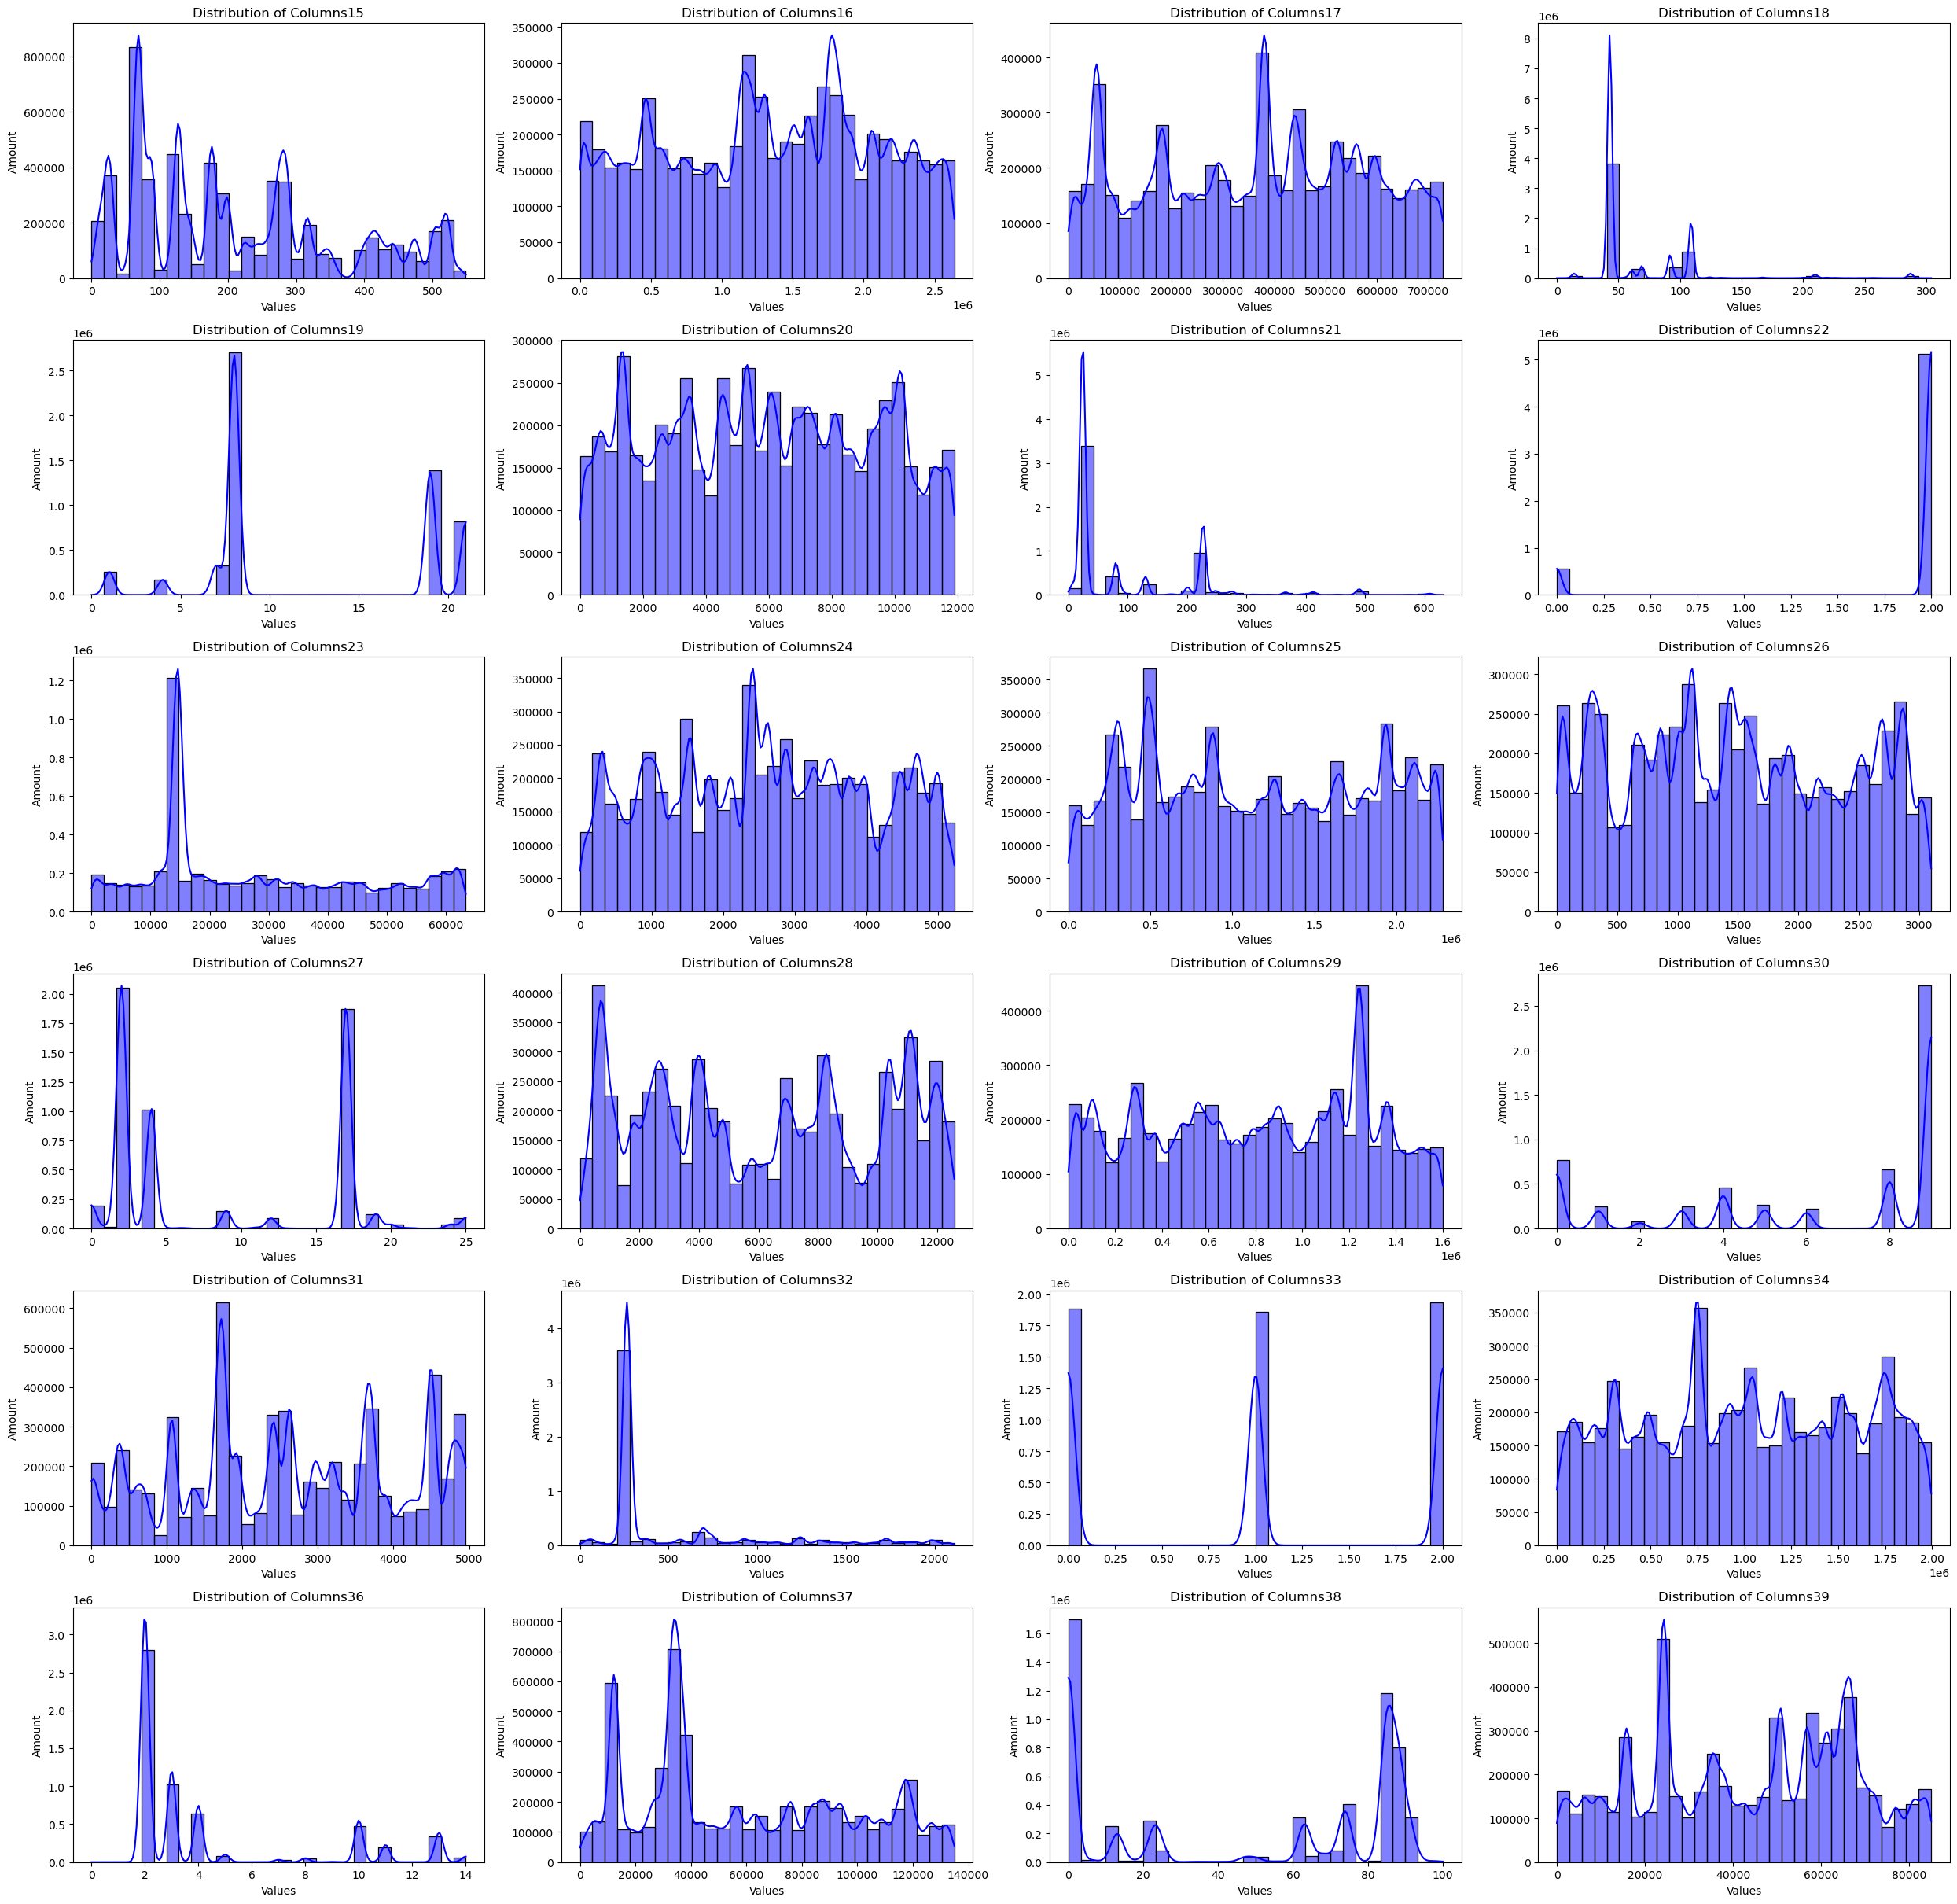

In [16]:
ColumnsHist(df_chunk2.iloc[:, 14:39])

In [10]:
SaveCSV(df_chunk2, '3.Final', '2')

Saved 3.Final Chunk 2
